<a href="https://colab.research.google.com/github/pc-repo/algorytmy-ewolucyjne/blob/main/AE_L4_65456.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AE_Lab_4**
Rozwiązywanie problemu komiwojażera z wykorzystaniem algorytmu ewolucyjnego

### **Zad 1.** Napisz najprostszy/edukacyjny przykład rozwiązania problemu komiwojażera z wykorzystaniem algorytmu ewolucyjnego

Definicje początkowe. Parametry algorytmu oraz inicjacja tablicy współrzędnych miast (o zadanej długości), a także interpretacja graficzna.

W zadaniu pominięto aspekt umiejscowienia placówki bazowej, a więc wyboru miasta startowego i co za tym idzie także tego samego na końcu. Wznaczana jest możliwie najkrótsza trasa.

[(58.457570518710355, 84.8224246525749), (57.09296941314225, 62.47364549794494), (75.58697075262066, 16.06569640850851), (22.91855266798214, 40.8383251975126), (78.68246137016229, 54.54909033392755), (51.463051241033796, 66.76108503506806), (10.978294576037296, 83.17956622809979), (80.96108360193462, 82.87657311864443), (41.83688463766623, 73.55230221427854), (21.54885552228436, 45.86833866026918)]


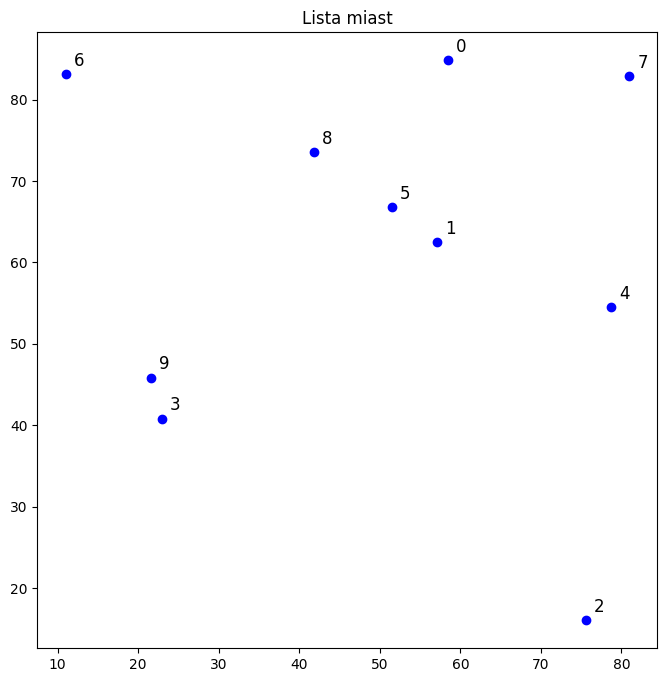

In [ ]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np


MUT_RATE = 0.05
POP_SIZE = 10
GENERACJA = 150
MIASTA_LEN = 10

# Tablica losowania współrzędnych (miast)
miasta = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(MIASTA_LEN)]
print(miasta)


# Mapka miast (graficzne ułożenie)
x = [miasto[0] for miasto in miasta]
y = [miasto[1] for miasto in miasta]

plt.figure(figsize=(8, 8))
plt.scatter(x, y, color='blue')

for i, (cx, cy) in enumerate(miasta):
    plt.text(cx + 1, cy + 1, str(i), fontsize=12)

plt.title("Lista miast")
plt.show()

Poniżej deklaracje funkcji obliczania odległości pomiędzy dwoma wybranymi miastami (na podstawie współrzędnych - pierwiastek z sumy kwadratów) oraz całkowitej drogi przebytej przez miasta dla danego ułożenia (przypadku trasy).

Definicja funkcji celu - lista tras (populacji) sortowana rosnąco wg. kryterium długości trasy (suma odcinków składowych - począwszy od krótszych przyrostów).

In [ ]:
# Dystans
def dystans(ax, ay):
    return math.sqrt((ax[0] - ay[0])**2 + (ax[1] - ay[1])**2)

# Długość drogi
def droga_dlugosc(route):
    return sum(dystans(miasta[route[i]], miasta[route[(i + 1) % len(route)]]) for i in range(len(route)))

# Funkcja celu wg. parametru oblicznej trasy (zwraca miasta w kolejności)
def fit(populacja):
    sort = sorted(populacja, key = droga_dlugosc)
    return sort



Inicjacja populacji początkowej oraz definicje algorytmu: selekcja turniejowa, krzyżowanie "z wycinaniem", mutacja "z wymianą".

Selekcja wybiera połowę osobników (wstępnie posortowanych? w pętli programu), z dokładnością do parzystości ilości elementów - stąd funkcja modulo 2, a następnie losuje jednego z nich.

Krzyżowanie dwupunktowe - OX (punkty x, y - gdzie x < y) ustala maskę do przekazania genów (miast). Z 1-rodzica wybiera przerwę (hole) od pozycji x do y - [x, y). Z 2-rodzica wybiera zakres [0, x) + [y, len) - stąd fragment "not in hole". I następnie zwraca złożenie tych fragmentów genów. Tu trzeba zauważyć, iż pętla for wywołana i przypisana do "child" sprawia, że "child" staje się krótsze. Stąd w złożeniu indeks "x" występuje dwukrotnie. Takie rozwiązanie gwarantuje zachowanie warunku prawidłowej permutacji.

Mutacja metodą wymiany również zapewnia zachowanie warunku prawidłowej permutacji.


In [ ]:
# Inicjacja populacji
def inicjacja(POP_SIZE):
    init = [random.sample(range(len(miasta)), len(miasta)) for _ in range(POP_SIZE)]
    return init


# Selekcja metodą turnieju
def selekcja(populacja):
    select = random.choice(populacja[:len(populacja) // 2])
    return select

# Krzyżowanie OX
def crossover(parent1, parent2):
    x, y = sorted(random.sample(range(len(parent1)), 2))
    hole = parent1[x:y]

    child = [i for i in parent2 if i not in hole]
    return child[:x] + hole + child[x:]

# Mutacja
def mutacja(droga, MUT_RATE):
    if random.random() < MUT_RATE:
      x, y = random.sample(range(len(droga)), 2)
      droga[x], droga[y] =  droga[y], droga[x]
    return droga

Główna pętla programu - obliczenia i wyprowadzenie wyniku.

In [ ]:
# Pętla programu

def algorytm():
    populacja = inicjacja(POP_SIZE)

    for gen in range(GENERACJA):
        populacja = fit(populacja)
        nowa_populacja = []

        for _ in range(POP_SIZE):
            parent1 = selekcja(populacja)
            parent2 = selekcja(populacja)

            child = crossover(parent1, parent2)
            child = mutacja(child, MUT_RATE)

            nowa_populacja.append(child)

        populacja = nowa_populacja

        if gen % 15 == 0:
          print(f"Generacja {gen}  najkrócej: {droga_dlugosc(fit(populacja)[0]):.2f}")

    # best = populacja[np.argmin([droga_dlugosc(id) for id in populacja])]
    best = fit(populacja)[0]
    print(f"Najlepsza trasa: {best}  o długości: {droga_dlugosc(best)}")


# Uruchomienie algorytmu
algorytm()

Generacja 0  najkrócej: 345.35
Generacja 15  najkrócej: 337.65
Generacja 30  najkrócej: 332.68
Generacja 45  najkrócej: 332.68
Generacja 60  najkrócej: 332.68
Generacja 75  najkrócej: 311.21
Generacja 90  najkrócej: 293.34
Generacja 105  najkrócej: 281.26
Generacja 120  najkrócej: 281.26
Generacja 135  najkrócej: 281.26
Najlepsza trasa: [8, 5, 0, 7, 1, 4, 2, 3, 9, 6]  o długości: 281.26408546810075


### **Zad 2.** Rozwiąż problem komiwojażera z wykorzystaniem poniższego algorytmu ewolucyjnego. Wykonaj pewną liczbę prób z wybranymi/ustalonymi parametrami ewolucyjnymi i na koniec przedstaw wnioski.

Pokolenie 1:
  Najlepszy osobnik: długość trasy = 570.74
  Najgorszy osobnik: długość trasy = 993.53
  Średnia długość trasy: 792.33

Pokolenie 11:
  Najlepszy osobnik: długość trasy = 483.14
  Najgorszy osobnik: długość trasy = 983.91
  Średnia długość trasy: 785.10



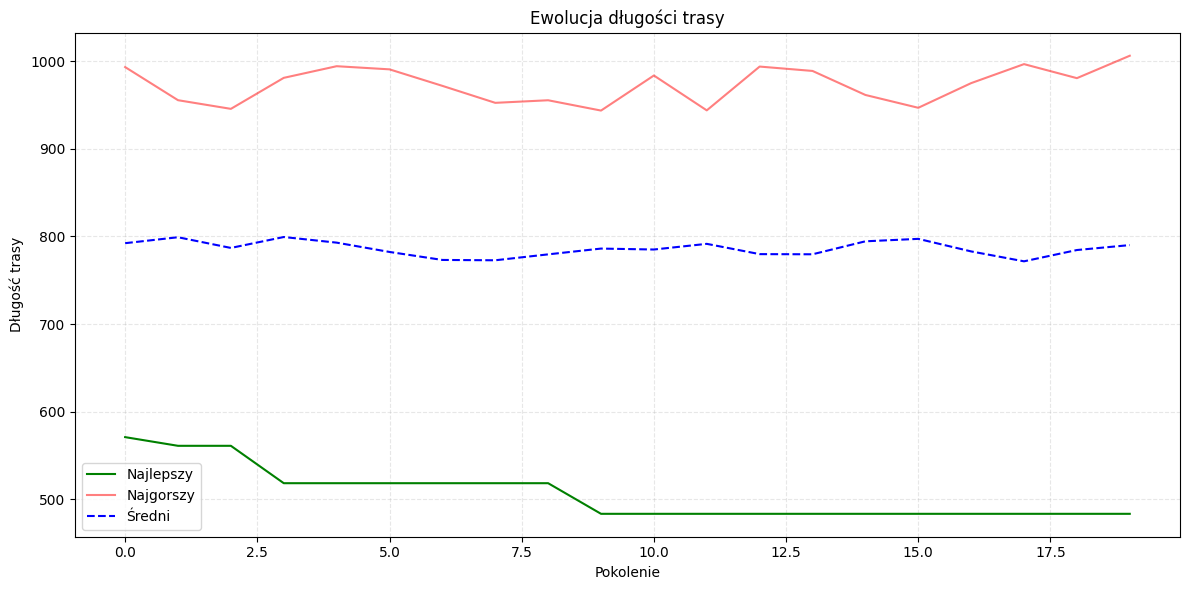

Najlepsza trasa: [6, 10, 5, 7, 9, 11, 13, 3, 0, 8, 1, 14, 12, 4, 2]
Najmniejsza długość trasy: 483.14


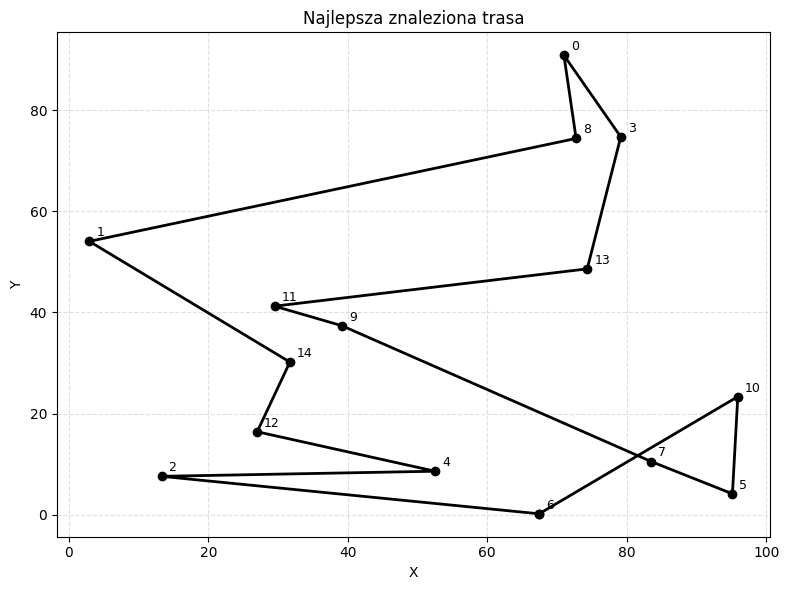

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Parametryzacja
pop_size = 100           # Liczba osobników w populacji
iterations = 20         # Liczba pokoleń (iteracji)
num_cities = 15          # Liczba miast

# Współrzędne miast (losowe)
city_positions = np.random.rand(num_cities, 2) * 100  # Miasta w przestrzeni 2D

# Funkcja oceny osobnika (fitness)
def fitness(route):
    distance = 0
    for i in range(len(route) - 1):
        city_a = city_positions[route[i]]
        city_b = city_positions[route[i + 1]]
        distance += np.linalg.norm(city_a - city_b)
    distance += np.linalg.norm(city_positions[route[-1]] - city_positions[route[0]])  # powrót do startu
    return distance

# Tworzenie początkowej populacji
def create_initial_population(pop_size, num_cities):
    return [random.sample(range(num_cities), num_cities) for _ in range(pop_size)]

# Selekcja kołem ruletki (z przeskalowaniem odwrotności)
def roulette_wheel_selection(population, fitness_values):
    inverse_fitness = 1 / (fitness_values + 1e-8)
    selection_probabilities = inverse_fitness / np.sum(inverse_fitness)
    return population[np.random.choice(len(population), p=selection_probabilities)]

# Selekcja turniejowa (opcjonalnie)
def tournament_selection(population, fitness_values, tournament_size=5):
    selected_indices = np.random.choice(len(population), tournament_size, replace=False)
    selected_fitness = fitness_values[selected_indices]
    winner_index = selected_indices[np.argmin(selected_fitness)]
    return population[winner_index]

# Krzyżowanie (Order Crossover - OX)
def order_crossover(parent1, parent2):
    size = len(parent1)
    p1, p2 = sorted(random.sample(range(size), 2))
    child = [-1] * size
    child[p1:p2] = parent1[p1:p2]
    current_pos = 0
    for city in parent2:
        if city not in child:
            while child[current_pos] != -1:
                current_pos += 1
            child[current_pos] = city
    return child

# Mutacja (zamiana miejsc)
def swap_mutation(route):
    i, j = random.sample(range(len(route)), 2)
    route[i], route[j] = route[j], route[i]
    return route

# Algorytm ewolucyjny
def evolutionary_algorithm():
    population = create_initial_population(pop_size, num_cities)
    best_fitness, worst_fitness, avg_fitness = [], [], []

    for generation in range(iterations):
        fitness_values = np.array([fitness(route) for route in population])
        new_population = []

        # Elitarny osobnik
        elite_index = np.argmin(fitness_values)
        new_population.append(population[elite_index])

        while len(new_population) < pop_size:
            # Selekcja
            parent1 = roulette_wheel_selection(population, fitness_values)
            parent2 = roulette_wheel_selection(population, fitness_values)
            # Krzyżowanie
            child = order_crossover(parent1, parent2)
            # Mutacja
            child = swap_mutation(child)
            new_population.append(child)

        population = new_population
        fitness_values = np.array([fitness(route) for route in population])

        # Statystyki
        best_value = np.min(fitness_values)
        worst_value = np.max(fitness_values)
        avg_value = np.mean(fitness_values)

        best_fitness.append(best_value)
        worst_fitness.append(worst_value)
        avg_fitness.append(avg_value)

        if generation % 10 == 0:
          print(f"Pokolenie {generation+1}:")
          print(f"  Najlepszy osobnik: długość trasy = {best_value:.2f}")
          print(f"  Najgorszy osobnik: długość trasy = {worst_value:.2f}")
          print(f"  Średnia długość trasy: {avg_value:.2f}\n")

    # Wykres postępu
    plt.figure(figsize=(12, 6))
    plt.plot(best_fitness, label='Najlepszy', color='green')
    plt.plot(worst_fitness, label='Najgorszy', color='red', alpha=0.5)
    plt.plot(avg_fitness, label='Średni', color='blue', linestyle='dashed')
    plt.title("Ewolucja długości trasy")
    plt.xlabel("Pokolenie")
    plt.ylabel("Długość trasy")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Najlepsze rozwiązanie
    best_route = population[np.argmin(fitness_values)]
    print(f"Najlepsza trasa: {best_route}")
    print(f"Najmniejsza długość trasy: {fitness(best_route):.2f}")

    # Wizualizacja trasy
    plot_best_route(best_route)

# Rysowanie najlepszej trasy
def plot_best_route(route):
    route_coords = city_positions[route + [route[0]]]  # zamknięcie pętli
    plt.figure(figsize=(8, 6))
    plt.plot(route_coords[:, 0], route_coords[:, 1], marker='o', color='black', linewidth=2)
    for i, pos in enumerate(city_positions):
        plt.text(pos[0]+1, pos[1]+1, str(i), fontsize=9)
    plt.title("Najlepsza znaleziona trasa")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# Uruchomienie algorytmu
evolutionary_algorithm()


Najwygodniej byłoby przedstawić grafiki z rozwiązaniami dla różnych wariantów użytych algorytmów składowych. Jednak ze względu na trudność w prezentowaniu plików graficznych w tym notatniku, ograniczę się do dwóch zrzutów ekranowych.

To co generalnie można zauważyć, to fakt, iż zmiana rozmiaru populacji skutkuje wygładzeniem przebiegu wartości najgorszych i średnich. Natomiast skutek tego wpływu na optymalne rozwiązanie jest znikomy. Poniżej zrzuty z dwoma ustawieniami rozmiaru populacji: 2 oraz 50.
https://drive.google.com/file/d/1T3vSr6vWrJqT1WknmA57Q5LT6K-LcUib/view?usp=sharing

Poniżej zrzut z dwoma ustawieniami ilości iteracji, tzn. obserwowanych generacji: 20 oraz 100. Widoczne jest podobieństwo na samym wykresie jeśli chodzi o sposób zmienności. Różnica w zagęszczeniu oscylacji jest wynikiem zwiększenia skali.
https://drive.google.com/file/d/1D43Qr-re4sdyI5uC_A2tvgN0XUfFRu5Q/view?usp=sharing

### **Zad 3.** Dla wybranych miast rozwiąż problem komiwojażera z wykorzystaniem poniższego algorytmu ewolucyjnego. Wykonaj pewną liczbę prób ze zmieniającymi się parametrami ewolucyjnymi i na koniec wczytaj zebrane w pliku dane do notatnika i przedstaw wnioski.

Pobieram współrzędne dla: Warszawa
Pobieram współrzędne dla: Zakopane
Pobieram współrzędne dla: Wrocław
Pobieram współrzędne dla: Gdańsk
Pobieram współrzędne dla: Łuków
Pobieram współrzędne dla: Siedlce
Pobieram współrzędne dla: Radzyń Podlaski
Pobieram współrzędne dla: Opole
Pobieram współrzędne dla: Toruń
Pobieram współrzędne dla: Szczecin
Pobieram współrzędne dla: Katowice
Pobieram współrzędne dla: Lublin
Pobieram współrzędne dla: Poznań
Pobieram współrzędne dla: Suwałki
Pobieram współrzędne dla: Piątek
Pokolenie 1: Najlepsza długość trasy: 3977.28 km
Pokolenie 51: Najlepsza długość trasy: 2913.67 km
Pokolenie 100: Najlepsza długość trasy: 2439.77 km


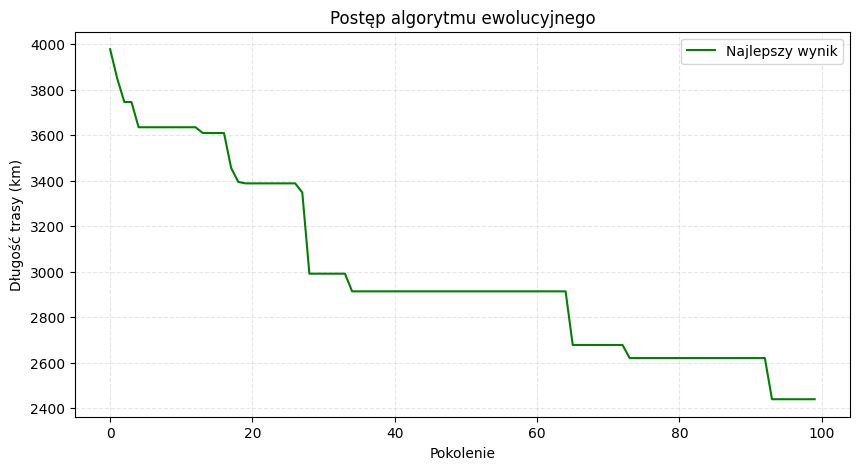

Najlepsza trasa: ['Poznań', 'Szczecin', 'Gdańsk', 'Toruń', 'Piątek', 'Wrocław', 'Opole', 'Katowice', 'Zakopane', 'Lublin', 'Łuków', 'Radzyń Podlaski', 'Siedlce', 'Suwałki', 'Warszawa']
Długość trasy: 2439.7656400938718 km


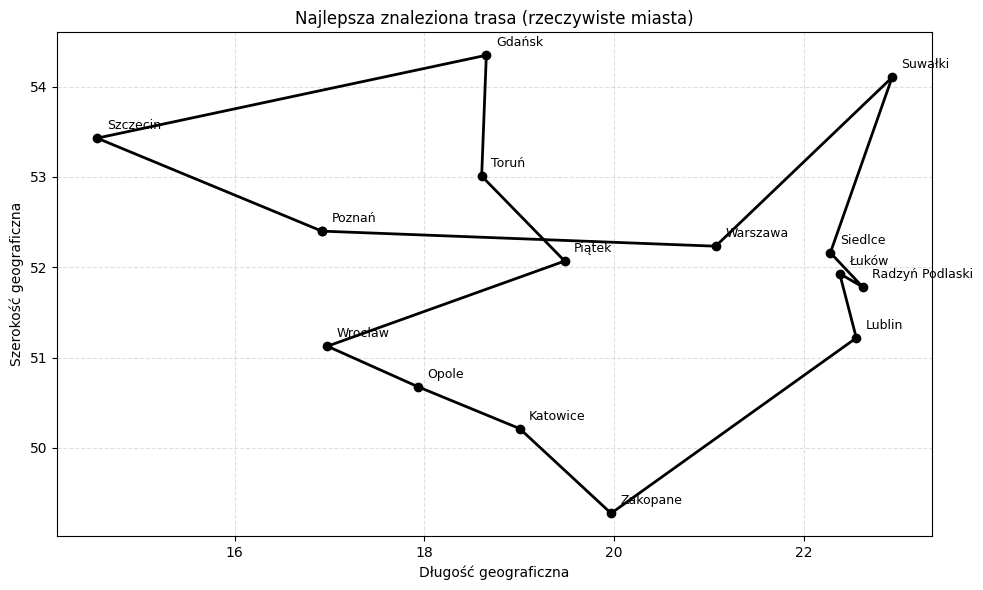

In [ ]:
import random
import numpy as np
import requests
from geopy.distance import geodesic
import matplotlib.pyplot as plt

# ==================== POBIERANIE WSPÓŁRZĘDNYCH Z OSM ====================

def get_city_coordinates(city_name):
    url = f'https://nominatim.openstreetmap.org/search?q={city_name}&format=json&addressdetails=1'
    headers = {'User-Agent': 'MyGeopyApp/1.0 (your-email@example.com)'}
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        data = response.json()
        if len(data) > 0:
            lat = float(data[0]['lat'])
            lon = float(data[0]['lon'])
            return lat, lon
        else:
            raise ValueError(f"Nie udało się znaleźć współrzędnych dla miasta: {city_name}")
    except requests.exceptions.RequestException as e:
        print(f"Błąd w zapytaniu: {e}")
        return None
    except ValueError as e:
        print(e)
        return None

def create_distance_matrix(cities):
    num_cities = len(cities)
    distance_matrix = np.zeros((num_cities, num_cities))
    coordinates = []
    for city in cities:
        print(f"Pobieram współrzędne dla: {city}")
        coords = get_city_coordinates(city)
        if coords:
            coordinates.append(coords)
        else:
            print(f"Nie udało się pobrać danych dla miasta {city}. Przerywam.")
            return None, None
    for i in range(num_cities):
        for j in range(i + 1, num_cities):
            distance = geodesic(coordinates[i], coordinates[j]).km
            distance_matrix[i][j] = distance
            distance_matrix[j][i] = distance
    return distance_matrix, coordinates

def save_best_route_to_file(route, distance, filename='best_routes_4.txt'):
    with open(filename, 'a') as file:
        # Zapisujemy wynik w nowym wierszu
        file.write(f"Trasa: {', '.join(route)} | Długość: {distance:.2f} km | Populacja: {pop_size} | Iteracje: {iterations}\n")

# ==================== ALGORYTM EWOLUCYJNY ====================

def create_initial_population(pop_size, num_cities):
    return [random.sample(range(num_cities), num_cities) for _ in range(pop_size)]

def fitness(route, distance_matrix):
    distance = 0
    for i in range(len(route) - 1):
        distance += distance_matrix[route[i]][route[i + 1]]
    distance += distance_matrix[route[-1]][route[0]]  # powrót do startu
    return distance

def roulette_wheel_selection(population, fitness_values):
    inverse_fitness = 1 / (fitness_values + 1e-8)
    selection_probabilities = inverse_fitness / np.sum(inverse_fitness)
    return population[np.random.choice(len(population), p=selection_probabilities)]

def order_crossover(parent1, parent2):
    size = len(parent1)
    p1, p2 = sorted(random.sample(range(size), 2))
    child = [-1] * size
    child[p1:p2] = parent1[p1:p2]
    current_pos = 0
    for city in parent2:
        if city not in child:
            while child[current_pos] != -1:
                current_pos += 1
            child[current_pos] = city
    return child

def swap_mutation(route):
    i, j = random.sample(range(len(route)), 2)
    route[i], route[j] = route[j], route[i]
    return route

def plot_best_route(route, coordinates, city_names):
    ordered_coords = [coordinates[i] for i in route] + [coordinates[route[0]]]
    lats, lons = zip(*ordered_coords)
    plt.figure(figsize=(10, 6))
    plt.plot(lons, lats, marker='o', color='black', linewidth=2)
    for i, city_idx in enumerate(route):
        plt.text(coordinates[city_idx][1]+0.1, coordinates[city_idx][0]+0.1, city_names[city_idx], fontsize=9)
    plt.title("Najlepsza znaleziona trasa (rzeczywiste miasta)")
    plt.xlabel("Długość geograficzna")
    plt.ylabel("Szerokość geograficzna")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# ==================== URUCHOMIENIE ALGORYTMU EWOLUCYJNEGO ====================

pop_size = 10
iterations = 100

def evolutionary_algorithm(cities, pop_size=pop_size, iterations=iterations):
    distance_matrix, coordinates = create_distance_matrix(cities)
    if distance_matrix is None:
        return

    num_cities = len(cities)
    population = create_initial_population(pop_size, num_cities)
    best_fitness = []

    for generation in range(iterations):
        fitness_values = np.array([fitness(route, distance_matrix) for route in population])
        new_population = []

        elite_index = np.argmin(fitness_values)
        new_population.append(population[elite_index])  # elita

        while len(new_population) < pop_size:
            parent1 = roulette_wheel_selection(population, fitness_values)
            parent2 = roulette_wheel_selection(population, fitness_values)
            child = order_crossover(parent1, parent2)
            child = swap_mutation(child)
            new_population.append(child)

        population = new_population
        fitness_values = np.array([fitness(route, distance_matrix) for route in population])

        best_value = np.min(fitness_values)
        best_fitness.append(best_value)

        if generation % 50 == 0 or generation == iterations - 1:
            print(f"Pokolenie {generation+1}: Najlepsza długość trasy: {best_value:.2f} km")

    # Wykres postępu
    plt.figure(figsize=(10, 5))
    plt.plot(best_fitness, label='Najlepszy wynik', color='green')
    plt.xlabel("Pokolenie")
    plt.ylabel("Długość trasy (km)")
    plt.title("Postęp algorytmu ewolucyjnego")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend()
    plt.show()

    # Wynik końcowy
    final_best_route = population[np.argmin(fitness_values)]
    print("Najlepsza trasa:", [cities[i] for i in final_best_route])
    final_distance = fitness(final_best_route, distance_matrix)
    print("Długość trasy:", final_distance, "km")
    plot_best_route(final_best_route, coordinates, cities)

    # Zapisz wynik do pliku
    save_best_route_to_file([cities[i] for i in final_best_route], final_distance)

# ==================== PRZYKŁADOWE MIASTA ====================

city_list = [
    "Warszawa", "Zakopane", "Wrocław", "Gdańsk", "Łuków", "Siedlce",
    "Radzyń Podlaski", "Opole", "Toruń", "Szczecin", "Katowice", "Lublin",
    "Poznań", "Suwałki", "Piątek"
]

evolutionary_algorithm(city_list)


Przy każdej próbie zastosowania zagadnienia, postęp algorytmu jest schodkowy. Wartości w kolejnych iteracjach schodkowo zbliżają się do minimum długości trasy. Wynik działania algorytmu nie jest wartością bezwzględnie minimalną a jedynie optymalną ze względu na użyte zasoby. Tu są one zdecydowanie oszczędne biorąc pod uwagę złożoność algorytmu sformułowanego analitycznie.

In [ ]:
# Wczytanie raportu z pliku tekstowego

# Ścieżka do pliku w katalogu /content
file_path = 'best_routes_4.txt'

# Wczytanie zawartości pliku
with open(file_path, 'r') as file:
    content = file.read()

# Wyświetlanie zawartości pliku
print(content)

Trasa: Suwałki, Lublin, Radzyń Podlaski, Łuków, Zakopane, Katowice, Opole, Poznań, Szczecin, Wrocław, Piątek, Siedlce, Warszawa, Toruń, Gdańsk | Długość: 2767.50 km | Populacja: 10 | Iteracje: 100
Trasa: Suwałki, Warszawa, Lublin, Radzyń Podlaski, Siedlce, Łuków, Piątek, Poznań, Szczecin, Opole, Wrocław, Katowice, Zakopane, Toruń, Gdańsk | Długość: 2731.16 km | Populacja: 10 | Iteracje: 100
Trasa: Łuków, Siedlce, Warszawa, Wrocław, Opole, Zakopane, Katowice, Suwałki, Gdańsk, Toruń, Szczecin, Poznań, Piątek, Lublin, Radzyń Podlaski | Długość: 2748.48 km | Populacja: 10 | Iteracje: 100
Trasa: Wrocław, Poznań, Szczecin, Toruń, Gdańsk, Łuków, Radzyń Podlaski, Lublin, Siedlce, Suwałki, Warszawa, Piątek, Katowice, Zakopane, Opole | Długość: 2526.37 km | Populacja: 10 | Iteracje: 100

